In [1]:
import numpy as np
import pandas as pd
import torch 
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("ranking_dataset.csv")
df.head()

,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
0,542,67,876,414,26,335,620,924,950,113,5,1,7,4,0,3,6,8,9,2
1,378,14,210,954,231,572,315,295,567,706,5,0,1,9,2,7,4,3,6,8
2,749,876,73,111,899,213,541,769,287,219,6,8,0,1,9,2,5,7,4,3
3,372,880,475,329,733,564,739,376,632,10,2,9,4,1,7,5,8,3,6,0
4,186,822,577,519,707,123,143,294,693,677,2,9,5,4,8,0,1,3,7,6


In [3]:
#splitting dataset into inputs(values given) and outputs(ranks)
val = df.iloc[: , 0:10]
rank = df.iloc[: , 10:]
val.head()
rank.head()
val = val.to_numpy()
rank = rank.to_numpy()
print(val)
print(rank)

[[542  67 876 ... 924 950 113]
 [378  14 210 ... 295 567 706]
 [749 876  73 ... 769 287 219]
 ...
 [449 552 620 ... 589 851 886]
 [491 746 689 ... 974 397 312]
 [787 529   1 ... 194 115 365]]
[[5 1 7 ... 8 9 2]
 [5 0 1 ... 3 6 8]
 [6 8 0 ... 7 4 3]
 ...
 [2 3 6 ... 4 8 9]
 [5 7 6 ... 9 4 2]
 [7 6 0 ... 3 2 4]]


# Building baseline models 

# 1) MLP

In [4]:
#defining the MLP class 
class MLP(nn.Module):
    def __init__(self , in_dim , output_dim , hid_dim):
        super().__init__()
        #creating a simple mlp structure in_dim --> hid_dim --> hid_dim --> output_dim
        self.in_dim = in_dim 
        self.output_dim = output_dim
        self.hid_dim = hid_dim
        self.layers = nn.Sequential(
            nn.Linear(in_dim , hid_dim),
            nn.BatchNorm1d(hid_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hid_dim , 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256 , output_dim*output_dim)
        )
    def forward(self , val):
        val = self.layers(val)
        return val.view(-1 , self.output_dim , self.output_dim)
    


In [5]:
def train(model ,train_data , val_data , epochs):
    #using gpu for computation
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    #defining optimizer 
    optimizer = torch.optim.Adam(model.parameters() , lr = 1e-4, weight_decay= 1e-5)
    loss_train = []
    loss_val= []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for val,rank in train_data:
            optimizer.zero_grad() # for clearing older gradients
            val = val.to(device)
            rank = rank.to(device)
            ranks = model(val.float()) #predicted ranks
            c_loss = F.cross_entropy(ranks.permute(0,2,1) , rank.long())
            c_loss.backward() #backpropogation step
            optimizer.step() #optimizer step
            total_loss += c_loss.item()
        loss_train.append(total_loss)
        model.eval()
        with torch.no_grad():
            total_loss_val = 0.0
            for val, ranks in val_data:
                val, ranks = val.to(device), ranks.to(device)
                outputs = model(val.float())
                loss = F.cross_entropy(outputs.permute(0,2,1) , ranks.long() ) #LLM used for dimension matching
                total_loss_val +=loss.item()
            loss_val.append(total_loss_val)
        print(f"Epoch : {epoch+1} Training Loss: {loss_train[epoch]:.2f} Validation Loss: {loss_val[epoch]:.2f}")



    return loss_train , loss_val #returning loss for visualization 
            

In [6]:
# creating dataset and dataloader
class Data(Dataset):
    def __init__(self , val , rank ):
        self.val = torch.tensor(val)
        self.rank = torch.tensor(rank)
    def __len__(self):
        return len(self.val)
    def __getitem__(self , idx):
        return self.val[idx] , self.rank[idx]
        

In [7]:
#creating training and validation data for model training and validation 
train_data = DataLoader(Data(val,rank) , batch_size = 512 , shuffle =True)
val_data = DataLoader(Data(val,rank) , batch_size = 128)

In [8]:
modelM= MLP(val.shape[1] , rank.shape[1] , 64)
epochs = 100
loss1 ,loss2 = train(modelM, train_data , val_data, epochs)

print(val.shape[1])

Epoch : 1 Training Loss: 47.51 Validation Loss: 181.20
Epoch : 2 Training Loss: 46.59 Validation Loss: 178.30
Epoch : 3 Training Loss: 45.85 Validation Loss: 175.65
Epoch : 4 Training Loss: 45.22 Validation Loss: 173.29
Epoch : 5 Training Loss: 44.60 Validation Loss: 171.09
Epoch : 6 Training Loss: 44.09 Validation Loss: 169.05
Epoch : 7 Training Loss: 43.60 Validation Loss: 167.13
Epoch : 8 Training Loss: 43.13 Validation Loss: 165.33
Epoch : 9 Training Loss: 42.73 Validation Loss: 163.64
Epoch : 10 Training Loss: 42.32 Validation Loss: 162.04
Epoch : 11 Training Loss: 41.95 Validation Loss: 160.44
Epoch : 12 Training Loss: 41.62 Validation Loss: 158.97
Epoch : 13 Training Loss: 41.27 Validation Loss: 157.57
Epoch : 14 Training Loss: 40.90 Validation Loss: 156.22
Epoch : 15 Training Loss: 40.64 Validation Loss: 154.92
Epoch : 16 Training Loss: 40.33 Validation Loss: 153.66
Epoch : 17 Training Loss: 40.02 Validation Loss: 152.52
Epoch : 18 Training Loss: 39.78 Validation Loss: 151.33
E

[47.51391100883484, 46.59468460083008, 45.85014057159424, 45.22391605377197, 44.60390663146973, 44.09178280830383, 43.602949380874634, 43.131784200668335, 42.730666160583496, 42.31720757484436, 41.94753336906433, 41.61745071411133, 41.268869400024414, 40.89989423751831, 40.64443778991699, 40.33473825454712, 40.01609230041504, 39.78087759017944, 39.44033634662628, 39.21853864192963, 39.0221483707428, 38.745513677597046, 38.50114464759827, 38.28744328022003, 38.08356487751007, 37.83196973800659, 37.708476543426514, 37.492533802986145, 37.2853399515152, 37.098756551742554, 36.94512605667114, 36.74597680568695, 36.561196088790894, 36.44571900367737, 36.29211974143982, 36.122491002082825, 35.98285472393036, 35.82793605327606, 35.71419084072113, 35.58596646785736, 35.41552448272705, 35.30396544933319, 35.24676752090454, 35.07223463058472, 34.97532272338867, 34.85479962825775, 34.72752916812897, 34.60111725330353, 34.533116579055786, 34.44977831840515, 34.288681507110596, 34.235976219177246, 

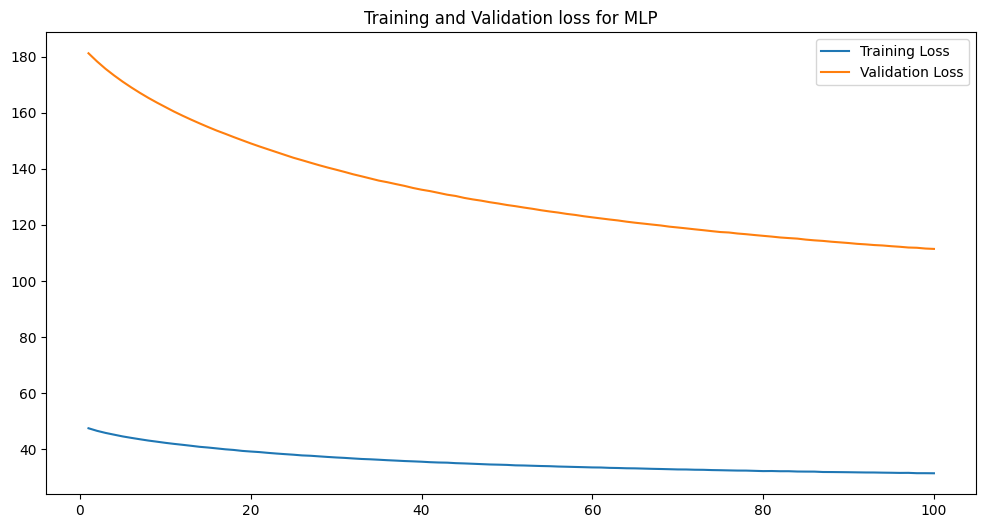

In [9]:
print(loss1)

plt.figure(figsize = (12,6))
x = np.arange(1 , epochs + 1)
plt.plot(x , loss1 , label = "Training Loss")
plt.plot(x , loss2, label = "Validation Loss")
plt.legend()
plt.title("Training and Validation loss for MLP")
plt.savefig("T&VLossMLP.png")

# 2)LSTMs



In [10]:
#creating a basic lstm model
class LSTM(nn.Module):
    def __init__(self,inp , hid , out , n_layers):
        super().__init__()
        self.inp = inp 
        self.hid = hid 
        self.out = out 
        self.lstm = nn.LSTM(inp , hid  , n_layers , batch_first = True, dropout= 0.3 , bidirectional = True)
        self.fc = nn.Sequential(
            nn.Linear(2*hid , 512),  #2* hidden_dim as the LSTM is bidirectional 
            nn.ReLU(),
            nn.Linear(512,128),
            nn.ReLU(),
            nn.Linear(128 , out*out) #we want a 10x10 matrice which has probability of rank of each number
        )
    def forward(self,x):
        #LLM used for dimension matching
        out , (h_n , c_n) = self.lstm(x)  #h_n is the hidden state of last timestamp and c_n is the cell state of last timestamp
        out = self.fc(out[:, -1, :])
        return out.view(-1 , self.out , self.out)
    

In [11]:
def train_LSTM(model ,train_data , val_data , epochs):
    #using gpu for computation
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    #defining optimizer 
    optimizer = torch.optim.Adam(model.parameters() , lr = 1e-4, weight_decay= 1e-5)
    loss_train = []
    loss_val= []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for val,rank in train_data:
            optimizer.zero_grad() # for clearing older gradients
            val = val.to(device)
            rank = rank.to(device)
            ranks = model(val.float().unsqueeze(1)) #predicted ranks
            c_loss = F.cross_entropy(ranks.permute(0,2,1) , rank.long())
            total_loss += c_loss.item()
            c_loss.backward() #backpropogation step
            optimizer.step() #optimizer step
        loss_train.append(total_loss)
        model.eval()
        with torch.no_grad():
            total_loss_val = 0.0
            for val, ranks in val_data:
                val, ranks = val.to(device), ranks.to(device)
                outputs = model(val.float().unsqueeze(1))
                loss = F.cross_entropy(outputs.permute(0,2,1,) , ranks.long())
                total_loss_val +=loss.item()
            loss_val.append(total_loss_val)
        print(f"Epoch : {epoch+1} Training Loss: {loss_train[epoch]:.2f} Validation Loss: {loss_val[epoch]:.2f}")



    return loss_train , loss_val #returning loss for visualization

In [12]:
n_layers = 2
epoch = 100
modelL= LSTM(val.shape[1] , 128 , rank.shape[1] , n_layers = n_layers)
loss_train , loss_val = train_LSTM(modelL, train_data , val_data , epochs = epoch)


Epoch : 1 Training Loss: 46.06 Validation Loss: 181.80
Epoch : 2 Training Loss: 46.00 Validation Loss: 181.47
Epoch : 3 Training Loss: 45.89 Validation Loss: 180.77
Epoch : 4 Training Loss: 45.64 Validation Loss: 179.18
Epoch : 5 Training Loss: 45.08 Validation Loss: 175.92
Epoch : 6 Training Loss: 44.08 Validation Loss: 170.83
Epoch : 7 Training Loss: 42.68 Validation Loss: 164.27
Epoch : 8 Training Loss: 41.04 Validation Loss: 157.32
Epoch : 9 Training Loss: 39.42 Validation Loss: 150.78
Epoch : 10 Training Loss: 37.87 Validation Loss: 144.46
Epoch : 11 Training Loss: 36.42 Validation Loss: 138.70
Epoch : 12 Training Loss: 35.08 Validation Loss: 133.23
Epoch : 13 Training Loss: 33.83 Validation Loss: 128.23
Epoch : 14 Training Loss: 32.66 Validation Loss: 123.49
Epoch : 15 Training Loss: 31.60 Validation Loss: 119.18
Epoch : 16 Training Loss: 30.65 Validation Loss: 115.43
Epoch : 17 Training Loss: 29.81 Validation Loss: 112.18
Epoch : 18 Training Loss: 29.11 Validation Loss: 109.39
E

[47.51391100883484, 46.59468460083008, 45.85014057159424, 45.22391605377197, 44.60390663146973, 44.09178280830383, 43.602949380874634, 43.131784200668335, 42.730666160583496, 42.31720757484436, 41.94753336906433, 41.61745071411133, 41.268869400024414, 40.89989423751831, 40.64443778991699, 40.33473825454712, 40.01609230041504, 39.78087759017944, 39.44033634662628, 39.21853864192963, 39.0221483707428, 38.745513677597046, 38.50114464759827, 38.28744328022003, 38.08356487751007, 37.83196973800659, 37.708476543426514, 37.492533802986145, 37.2853399515152, 37.098756551742554, 36.94512605667114, 36.74597680568695, 36.561196088790894, 36.44571900367737, 36.29211974143982, 36.122491002082825, 35.98285472393036, 35.82793605327606, 35.71419084072113, 35.58596646785736, 35.41552448272705, 35.30396544933319, 35.24676752090454, 35.07223463058472, 34.97532272338867, 34.85479962825775, 34.72752916812897, 34.60111725330353, 34.533116579055786, 34.44977831840515, 34.288681507110596, 34.235976219177246, 

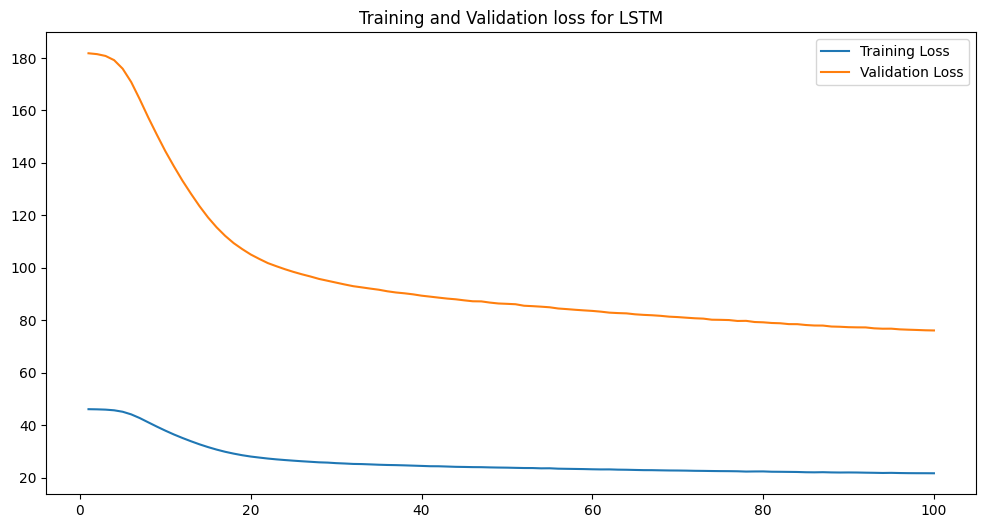

In [13]:
print(loss1)
#visualizing change in loss over each epoch 
plt.figure(figsize = (12,6))
x = np.arange(1 , epochs + 1)
plt.plot(x , loss_train , label = "Training Loss")
plt.plot(x , loss_val, label = "Validation Loss")
plt.legend()
plt.title("Training and Validation loss for LSTM")
plt.savefig("T&VLosslstm.png")

# Predicting using MLP and LSTM 

In [14]:
# creating dataset for testing the model 
X_train , X_test , y_train , y_test = train_test_split(
    val,
    rank,
    test_size = 0.1,
    random_state= 42
)

In [23]:
# for predicting the result 
def predict_mlp(model, X):
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    with torch.no_grad():
        X_tensor = torch.tensor(X).float()
        X_tensor = X_tensor.to(device)
        predictions = model(X_tensor)
        rankings = torch.argmax(predictions , dim = 2) #in the 10x10 matrice , taking the max of probability of ranks and labeling the number with same rank 
        rankings = rankings.cpu()
    return rankings.numpy()
   

In [24]:

def predict_lstm(model, X):
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    with torch.no_grad():
        X_tensor = torch.tensor(X).float().unsqueeze(1)
        X_tensor = X_tensor.to(device)
        predictions = model(X_tensor)
        rankings = torch.argmax(predictions , dim = 2) #in the 10x10 matrice , taking the max of probability of ranks and labeling the number with same rank
        rankings = rankings.cpu()
    return rankings.numpy()

In [25]:
predictions_mlp = predict_mlp(modelM , X_test)
print(predictions_mlp)
predictions_lstm = predict_lstm(modelL , X_test)
print(predictions_lstm)

[[0 0 9 ... 8 4 5]
 [9 8 1 ... 2 9 4]
 [1 9 8 ... 7 2 7]
 ...
 [9 6 2 ... 8 1 9]
 [5 9 0 ... 0 5 9]
 [6 6 2 ... 3 0 3]]
[[0 0 8 ... 6 5 4]
 [9 8 0 ... 2 9 4]
 [2 9 8 ... 5 3 7]
 ...
 [9 7 3 ... 6 2 8]
 [4 9 1 ... 1 6 7]
 [6 5 1 ... 3 0 3]]


# Accuracy per input 

In [26]:
# Using token_level_accuracy metric to evaluate the accuracy of the output from the model
def token_level_acc(pred , true):
    n = len(pred[0])
    sum = 0 
    for i in range(len(pred)):
        total = 0
        for j in range(n):
            if pred[i][j] == true[i][j]:
                total+=1
        percentage = total/n
        sum+=percentage
    return (sum/len(pred))*100

In [27]:
acc_lstm = token_level_acc(predictions_lstm , y_test)
acc_mlp = token_level_acc(predictions_mlp , y_test)

In [28]:
print(f"Accuracy percentage of LSTM: {acc_lstm:.2f} , Accuracy percentage of MLP: {acc_mlp:.2f}")

Accuracy percentage of LSTM: 57.30 , Accuracy percentage of MLP: 49.68


In [31]:
model_seq = [
    [1,2,3,4,5,6,7,8,9,10],
    [5,5,5,5,5,5,5,5,5,5],
    [1000,900,800,700,600,500,400,300,200,100],
    [20,40,60,80,100,120,140,160,180,200],
    [4000,6000,2000,1000,10000,8500,15000,20000,17500,500]
]
pred_l = predict_lstm(modelL , model_seq)
pred_m = predict_mlp(modelM , model_seq)
model_seq_pred = [
    [0,1,2,3,4,5,6,7,8,9],
    [0,0,0,0,0,0,0,0,0,0],
    [9,8,7,6,5,4,3,2,1,0],
    [0,1,2,3,4,5,6,7,8,9],
    [3,4,2,1,6,5,7,9,8,0],
]


In [32]:
print(token_level_acc(pred_l , model_seq_pred))
print(token_level_acc(pred_m , model_seq_pred))

46.0
34.0
